# 04 - Generate Submission

**March Madness 2026**

Uses ensemble predictions combining LogReg, XGBoost, and Neural Network.

In [16]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from pathlib import Path

from src.features import build_matchup_df, _parse_matchup_id
from src.model import (
    LogisticBaseline,
    XGBBaseline,
    MarchMadnessTrainer,
    EnsemblePredictor
)

DATA_DIR = Path('../data/raw')
PROC_DIR = Path('../data/processed')
OUT_DIR = Path('../outputs')
MODELS_DIR = Path('../models')

## 1. Load Model Results

In [17]:
with open(PROC_DIR / 'model_results.json') as f:
    results = json.load(f)

print("Model results:")
#print(json.dumps(results, indent=2))

m_feature_cols = results['M']['feature_cols']
w_feature_cols = results['W']['feature_cols']

m_best = results['M']['best_model']
w_best = results['W']['best_model']

print(f"\nUsing for Men's: {m_best}")
print(f"Using for Women's: {w_best}")

Model results:

Using for Men's: ensemble
Using for Women's: nn


## 2. Load Team Features and Build Prediction Matchups

In [18]:
m_feats = pd.read_csv(PROC_DIR / 'M_team_features.csv')
w_feats = pd.read_csv(PROC_DIR / 'W_team_features.csv')

# Rebuild prediction matchups to ensure feature columns match
m_pred_df, _ = build_matchup_df(m_feats, gender='M', mode='predict', include_interactions=True)
w_pred_df, _ = build_matchup_df(w_feats, gender='W', mode='predict', include_interactions=True)

print(f"Men's 2026 matchups: {m_pred_df.shape}")
print(f"Women's 2026 matchups: {w_pred_df.shape}")

# Check for missing features
m_miss = m_pred_df[m_feature_cols].isnull().mean()
print(f"\nMen's missing features: {(m_miss > 0).sum()}")


[M] Building matchup DataFrame (mode=predict)...
[M] Matchup shape: (66430, 148)
[M] Feature breakdown:
         Diff features: 45
         Ratio features: 5
         Interaction features: 3
         Total: 53

[W] Building matchup DataFrame (mode=predict)...
[W] Matchup shape: (65703, 130)
[W] Feature breakdown:
         Diff features: 39
         Ratio features: 5
         Interaction features: 3
         Total: 47
Men's 2026 matchups: (66430, 148)
Women's 2026 matchups: (65703, 130)

Men's missing features: 1


## 3. Load Saved Models

In [19]:
# Load Men's models
print("Loading Men's models...")

m_logreg = LogisticBaseline()
m_logreg.load(tag='M')

m_nn = MarchMadnessTrainer()
m_nn.load(tag='M')

# Try to load XGBoost if available
try:
    m_xgb = XGBBaseline()
    m_xgb.load(tag='M')
    print("XGBoost model loaded")
    has_xgb = True
except:
    print("No XGBoost model found")
    m_xgb = None
    has_xgb = False

Loading Men's models...
Using Apple MPS (GPU)
Model M loaded successfully
XGBoost model loaded


In [20]:
# Load Women's models
print("\nLoading Women's models...")

w_logreg = LogisticBaseline()
w_logreg.load(tag='W')

w_nn = MarchMadnessTrainer()
w_nn.load(tag='W')


Loading Women's models...
Using Apple MPS (GPU)
Model W loaded successfully


## 4. Create Ensemble Predictors

In [21]:
# Men's ensemble
if has_xgb:
    m_ensemble = EnsemblePredictor(
        models=[m_logreg, m_xgb, m_nn],
        weights=results['M'].get('ensemble_weights', [0.2, 0.3, 0.5])
    )
    print("Men's ensemble: LogReg + XGBoost + NN")
else:
    m_ensemble = EnsemblePredictor(
        models=[m_logreg, m_nn],
        weights=[0.3, 0.7]
    )
    print("Men's ensemble: LogReg + NN")

# Women's - use best single model or ensemble
if w_best == 'logreg':
    w_model = w_logreg
    print("Women's: using LogReg only")
else:
    w_model = EnsemblePredictor(
        models=[w_logreg, w_nn],
        weights=[0.3, 0.7]
    )
    print("Women's ensemble: LogReg + NN")

Men's ensemble: LogReg + XGBoost + NN
Women's ensemble: LogReg + NN


## 5. Generate Predictions

In [22]:
# Men's predictions
m_X_pred = m_pred_df[m_feature_cols].values

if m_best == 'ensemble':
    m_probs = m_ensemble.predict_proba(m_X_pred)
else:
    m_probs = m_nn.predict_proba(m_X_pred)

print(f"Men's predictions: {m_probs.shape}")
print(f"  Min={m_probs.min():.4f}  Max={m_probs.max():.4f}  Mean={m_probs.mean():.4f}")

# Women's predictions
w_X_pred = w_pred_df[w_feature_cols].values
w_probs = w_model.predict_proba(w_X_pred)

print(f"\nWomen's predictions: {w_probs.shape}")
print(f"  Min={w_probs.min():.4f}  Max={w_probs.max():.4f}  Mean={w_probs.mean():.4f}")

Men's predictions: (66430,)
  Min=0.0018  Max=0.9962  Mean=0.4736

Women's predictions: (65703,)
  Min=0.0000  Max=1.0000  Mean=0.4783


## 6. Build Submission DataFrame

In [23]:
m_sub = pd.DataFrame({'ID': m_pred_df['ID'].values, 'Pred': m_probs})
w_sub = pd.DataFrame({'ID': w_pred_df['ID'].values, 'Pred': w_probs})

submission = pd.concat([m_sub, w_sub], ignore_index=True)
submission['Pred'] = submission['Pred'].fillna(0.5)

print(f"Combined submission shape: {submission.shape}")
print(f"\nFirst 5 rows:")
print(submission.head())
print(f"\nLast 5 rows:")
print(submission.tail())

Combined submission shape: (132133, 2)

First 5 rows:
               ID      Pred
0  2026_1101_1102  0.862644
1  2026_1101_1103  0.009643
2  2026_1101_1104  0.014566
3  2026_1101_1105  0.726038
4  2026_1101_1106  0.687805

Last 5 rows:
                    ID      Pred
132128  2026_3478_3480  0.216374
132129  2026_3478_3481  0.088507
132130  2026_3479_3480  0.427898
132131  2026_3479_3481  0.110904
132132  2026_3480_3481  0.150966


## 7. Validate Against Sample Submission

In [24]:
sample = pd.read_csv(DATA_DIR / 'SampleSubmissionStage2.csv')

print("=== Validation ===")
assert len(submission) == len(sample), f"Row count mismatch: {len(submission)} vs {len(sample)}"
print(f"[OK] Row count matches: {len(submission)}")

missing_ids = set(sample['ID']) - set(submission['ID'])
extra_ids = set(submission['ID']) - set(sample['ID'])
print(f"[OK] Missing IDs: {len(missing_ids)}")
print(f"[OK] Extra IDs: {len(extra_ids)}")

assert submission['Pred'].between(0, 1).all()
print(f"[OK] All predictions in [0, 1]")
print(f"[OK] NaN predictions: {submission['Pred'].isna().sum()}")

print(f"\nPrediction distribution:")
print(submission['Pred'].describe())

=== Validation ===
[OK] Row count matches: 132133
[OK] Missing IDs: 0
[OK] Extra IDs: 0
[OK] All predictions in [0, 1]
[OK] NaN predictions: 0

Prediction distribution:
count    1.321330e+05
mean     4.759584e-01
std      3.263080e-01
min      1.000000e-07
25%      1.897158e-01
50%      4.827715e-01
75%      7.355806e-01
max      9.999999e-01
Name: Pred, dtype: float64


## 8. Prediction Distribution Plot

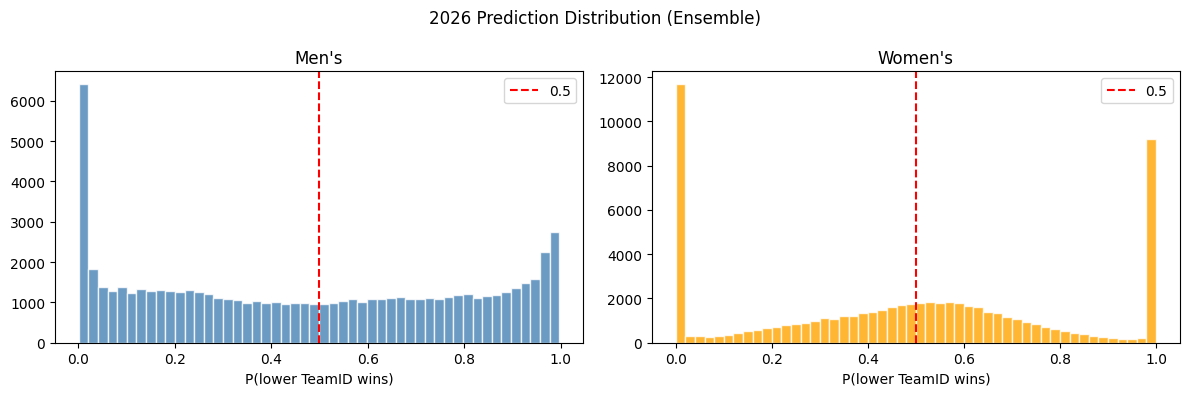

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('2026 Prediction Distribution (Ensemble)')

axes[0].hist(m_probs, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0.5, color='red', linestyle='--', label='0.5')
axes[0].set_title("Men's")
axes[0].set_xlabel('P(lower TeamID wins)')
axes[0].legend()

axes[1].hist(w_probs, bins=50, color='orange', edgecolor='white', alpha=0.8)
axes[1].axvline(0.5, color='red', linestyle='--', label='0.5')
axes[1].set_title("Women's")
axes[1].set_xlabel('P(lower TeamID wins)')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'prediction_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Team Lookup Helper

In [26]:
m_teams = pd.read_csv(DATA_DIR / 'MTeams.csv')
w_teams = pd.read_csv(DATA_DIR / 'WTeams.csv')
all_teams = pd.concat([m_teams, w_teams], ignore_index=True)
team_lookup = dict(zip(all_teams['TeamID'], all_teams['TeamName']))

def lookup_team(team_id):
    return team_lookup.get(int(team_id), f'Unknown({team_id})')

def decode_matchup(matchup_id):
    parts = matchup_id.split('_')
    return f"{parts[0]}: {lookup_team(parts[1])} vs {lookup_team(parts[2])}"

# Enrich submission for inspection
def enrich_submission(sub_df):
    enriched = sub_df.copy()
    parts = enriched['ID'].str.split('_', expand=True)
    enriched['Season'] = parts[0].astype(int)
    enriched['TeamA_ID'] = parts[1].astype(int)
    enriched['TeamB_ID'] = parts[2].astype(int)
    enriched['TeamA_Name'] = enriched['TeamA_ID'].map(team_lookup)
    enriched['TeamB_Name'] = enriched['TeamB_ID'].map(team_lookup)
    enriched['P_A_wins'] = enriched['Pred'].round(4)
    enriched['P_B_wins'] = (1 - enriched['Pred']).round(4)
    return enriched[['ID', 'TeamA_Name', 'TeamA_ID', 'TeamB_Name', 'TeamB_ID',
                     'P_A_wins', 'P_B_wins']]

all_enriched = enrich_submission(submission)
print(f"Teams loaded: {len(team_lookup)}")
print(all_enriched.head())

Teams loaded: 760
               ID   TeamA_Name  TeamA_ID   TeamB_Name  TeamB_ID  P_A_wins  \
0  2026_1101_1102  Abilene Chr      1101    Air Force      1102    0.8626   
1  2026_1101_1103  Abilene Chr      1101        Akron      1103    0.0096   
2  2026_1101_1104  Abilene Chr      1101      Alabama      1104    0.0146   
3  2026_1101_1105  Abilene Chr      1101  Alabama A&M      1105    0.7260   
4  2026_1101_1106  Abilene Chr      1101   Alabama St      1106    0.6878   

   P_B_wins  
0    0.1374  
1    0.9904  
2    0.9854  
3    0.2740  
4    0.3122  


In [27]:
def matchup_checker(team_a, team_b, gender="M"):
    """Look up prediction for a specific matchup."""
    df = all_enriched.copy()
    
    if gender == "W":
        df = df[df['TeamA_ID'] >= 3000]
    else:
        df = df[df['TeamA_ID'] < 3000]
    
    # Find team IDs
    team_a_row = df[df['TeamA_Name'] == team_a]
    team_b_row = df[df['TeamB_Name'] == team_b]
    
    if len(team_a_row) == 0 or len(team_b_row) == 0:
        # Try swapping
        team_a_row = df[df['TeamB_Name'] == team_a]
        team_b_row = df[df['TeamA_Name'] == team_b]
        if len(team_a_row) > 0 and len(team_b_row) > 0:
            team_a, team_b = team_b, team_a
    
    return df[(df['TeamA_Name'] == team_a) & (df['TeamB_Name'] == team_b)]

# Example lookup
print("Example matchup lookup:")
matchup_checker('McNeese St', 'Vanderbilt')

Example matchup lookup:


,ID,TeamA_Name,TeamA_ID,TeamB_Name,TeamB_ID,P_A_wins,P_B_wins
45882,2026_1270_1435,McNeese St,1270,Vanderbilt,1435,0.3868,0.6132


## 10. Save Submission

In [28]:
out_path = OUT_DIR / 'submission.csv'
submission.to_csv(out_path, index=False)

print(f"Submission saved to {out_path}")
print(f"Shape: {submission.shape}")
print(f"\nFirst 10 rows:")
print(submission.head(10).to_string())

Submission saved to ../outputs/submission.csv
Shape: (132133, 2)

First 10 rows:
               ID      Pred
0  2026_1101_1102  0.862644
1  2026_1101_1103  0.009643
2  2026_1101_1104  0.014566
3  2026_1101_1105  0.726038
4  2026_1101_1106  0.687805
5  2026_1101_1107  0.689249
6  2026_1101_1108  0.781473
7  2026_1101_1110  0.463246
8  2026_1101_1111  0.228338
9  2026_1101_1112  0.004474


### Upload Commands

```bash
# Stage 2 (2026 tournament)
kaggle competitions submit -c march-machine-learning-mania-2026 \
    -f outputs/submission.csv \
    -m "Stage 2: Enhanced features + Ensemble"
```

### Next Steps
1. Upload Stage 1 submission to verify improvement over baseline
2. Compare Stage 1 leaderboard score vs local validation Brier
3. When 2026 seeds are announced, re-run feature pipeline and generate new predictions
4. Upload Stage 2 submission before tournament deadline

# EXTRA FUN

In [29]:
# SETTING UP MENS TOURNAMENT FOR SIMULATION
all_enriched_m = all_enriched[all_enriched['TeamA_ID'] < 2000].reset_index(drop=True)
all_names_in_df = pd.concat([
    all_enriched_m[['TeamA_Name']].rename(columns={'TeamA_Name': 'name'}),
    all_enriched_m[['TeamB_Name']].rename(columns={'TeamB_Name': 'name'})
]).drop_duplicates()['name'].tolist()

bracket_raw = [
    # East
    ("East",  1,  "Duke",            16, "Siena"),
    ("East",  8,  "Ohio St",       9, "TCU"),
    ("East",  5,  "St John's",      12, "Northern Iowa"),
    ("East",  4,  "Kansas",          13, "Cal Baptist"),
    ("East",  6,  "Louisville",      11, "South Florida"),
    ("East",  3,  "Michigan St",  14, "North Dakota St"),
    ("East",  7,  "UCLA",            10, "UCF"),
    ("East",  2,  "Connecticut",           15, "Furman"),
    # West
    ("West",  1,  "Arizona",         16, "LIU Brooklyn"),
    ("West",  8,  "Villanova",        9, "Utah St"),
    ("West",  5,  "Wisconsin",       12, "High Point"),
    ("West",  4,  "Arkansas",        13, "Hawaii"),
    ("West",  6,  "BYU",             11, "Texas/NC St"),
    ("West",  3,  "Gonzaga",         14, "Kennesaw St"),
    ("West",  7,  "Miami FL",      10, "Missouri"),
    ("West",  2,  "Purdue",          15, "Queens NC"),
    # Midwest
    ("Midwest", 1, "Michigan",       16, "UMBC/Howard"),
    ("Midwest", 8, "Georgia",         9, "St Louis"),
    ("Midwest", 5, "Texas Tech",     12, "Akron"),
    ("Midwest", 4, "Alabama",        13, "Hofstra"),
    ("Midwest", 6, "Tennessee",      11, "Miami (OH)/SMU"),
    ("Midwest", 3, "Virginia",       14, "Wright State"),
    ("Midwest", 7, "Kentucky",       10, "Santa Clara"),
    ("Midwest", 2, "Iowa St",     15, "Tennessee St"),
    # South
    ("South",  1,  "Florida",        16, "PVAMU/Lehigh"),
    ("South",  8,  "Clemson",         9, "Iowa"),
    ("South",  5,  "Vanderbilt",     12, "McNeese"),
    ("South",  4,  "Nebraska",       13, "Troy"),
    ("South",  6,  "North Carolina",            11, "VCU"),
    ("South",  3,  "Illinois",       14, "Penn"),
    ("South",  7,  "St Mary's CA",   10, "Texas A&M"),
    ("South",  2,  "Houston",        15, "Idaho"),
]

all_bracket_names = sorted(set(
    [t for _, _, t, _, _ in bracket_raw] +
    [t for _, _, _, _, t in bracket_raw]
))

name_map = {}
for bname in all_bracket_names:
    if bname in all_names_in_df:
        name_map[bname] = bname
        continue
    candidates = [n for n in all_names_in_df
                  if bname.lower() in n.lower() or n.lower() in bname.lower()]
    if len(candidates) == 1:
        name_map[bname] = candidates[0]

# manual fixes - updating play in results
manual_fixes = {
    "Texas/NC State":     "Texas",
    "UMBC/Howard":        "Howard",
    "Miami (OH)/SMU":     "SMU",
    "PVAMU/Lehigh":       "Lehigh",
}
name_map.update(manual_fixes)

# setting up seed structures
seed_order = [1, 8, 5, 4, 6, 3, 7, 2]
regions = ["East", "West", "Midwest", "South"]

bracket_by_region = {}
for region in regions:
    region_games = [(s1, t1, s2, t2)
                    for (r, s1, t1, s2, t2) in bracket_raw if r == region]
    region_games.sort(key=lambda x: seed_order.index(min(x[0], x[2])))
    bracket_by_region[region] = region_games

In [30]:
# ── 3. Lookup helper ─────────────────────────────────────────────────────────
def get_prob_a_wins(team_a, team_b, df, name_map):
    """
    Given two bracket names, return P(team_a beats team_b).
    Handles alphabetical ordering in the df.
    """
    na = name_map.get(team_a, team_a)
    nb = name_map.get(team_b, team_b)

    row = df[
        ((df['TeamA_Name'] == na) & (df['TeamB_Name'] == nb)) |
        ((df['TeamA_Name'] == nb) & (df['TeamB_Name'] == na))
    ]

    if len(row) == 0:
        print(f"  WARNING: matchup not found: '{na}' vs '{nb}'")
        return 0.5

    row = row.iloc[0]
    if row['TeamA_Name'] == na:
        return row['P_A_wins']
    else:
        return row['P_B_wins']


# ── 4. Build bracket structure ───────────────────────────────────────────────
# Each region: seeds paired in standard NCAA bracket order
# Bracket slots: (1v16), (8v9), (5v12), (4v13), (6v11), (3v14), (7v10), (2v15)
# Round of 32 pairings: winners of (1v16)vs(8v9), (5v12)vs(4v13),
#                                   (6v11)vs(3v14), (7v10)vs(2v15)
# Sweet 16: winners of first two R32 games vs winners of last two R32 games
# Elite 8:  winners of two S16 games
# Final Four: region winners face each other (East vs West, Midwest vs South)
# Championship: Final Four winners

regions = ["East", "West", "Midwest", "South"]

# Build dict: region -> list of 8 first-round matchups in bracket order
bracket_by_region = {}
seed_order = [1, 8, 5, 4, 6, 3, 7, 2]  # standard NCAA bracket slot order

for region in regions:
    region_games = [(s1, t1, s2, t2)
                    for (r, s1, t1, s2, t2) in bracket_raw if r == region]
    # Sort by seed_order position of the higher seed
    region_games.sort(key=lambda x: seed_order.index(min(x[0], x[2])))
    bracket_by_region[region] = region_games


# ── 5. Core simulation ────────────────────────────────────────────────────────
def simulate_region(region_games, df, name_map):
    """
    For all 16 teams in a region, compute P(reaching each round).
    Returns dict: team_name -> {round: probability}
    """
    # teams[i] = (bracket_name, seed)
    # slot order after sorting: 0:(1v16), 1:(8v9), 2:(5v12), 3:(4v13),
    #                            4:(6v11), 5:(3v14), 6:(7v10), 7:(2v15)

    # Build slot list: each slot is [teamA, teamB]
    slots = [(t1, t2) for (_, t1, _, t2) in region_games]

    # prob_reach[team][round] = probability team reaches that round
    # Rounds: R64, R32, S16, E8, F4 (within region)
    all_teams = [t for slot in slots for t in slot]
    prob = {t: {
        'Round_64':   1.0,   # already in tournament
        'Round_32':   0.0,
        'Sweet_16':   0.0,
        'Elite_8':    0.0,
        'Final_Four': 0.0,
    } for t in all_teams}

    # ── Round of 64 → Round of 32 ──
    # 8 games, winners advance
    # r32_probs[i] = {team: P(team wins slot i)}
    r32_probs = []
    for (ta, tb) in slots:
        p = get_prob_a_wins(ta, tb, df, name_map)
        r32_probs.append({ta: p, tb: 1 - p})
        prob[ta]['Round_32'] = p
        prob[tb]['Round_32'] = 1 - p

    # ── Round of 32 → Sweet 16 ──
    # Slots pair up: (0,1), (2,3), (4,5), (6,7)
    s16_probs = []
    for i in range(0, 8, 2):
        slot_left, slot_right = i, i + 1
        teams_left  = list(r32_probs[slot_left].keys())
        teams_right = list(r32_probs[slot_right].keys())
        s16_slot = {}
        for tl in teams_left:
            for tr in teams_right:
                p_tl_here = r32_probs[slot_left][tl]
                p_tr_here = r32_probs[slot_right][tr]
                p_tl_wins = get_prob_a_wins(tl, tr, df, name_map)
                prob[tl]['Sweet_16'] += p_tl_here * p_tr_here * p_tl_wins
                prob[tr]['Sweet_16'] += p_tl_here * p_tr_here * (1 - p_tl_wins)
                s16_slot[tl] = s16_slot.get(tl, 0) + p_tl_here * p_tr_here * p_tl_wins
                s16_slot[tr] = s16_slot.get(tr, 0) + p_tl_here * p_tr_here * (1 - p_tl_wins)
        s16_probs.append(s16_slot)

    # ── Sweet 16 → Elite 8 ──
    # Pairs: (s16_probs[0], s16_probs[1]), (s16_probs[2], s16_probs[3])
    e8_probs = []
    for i in range(0, 4, 2):
        left, right = s16_probs[i], s16_probs[i + 1]
        e8_slot = {}
        for tl, p_tl in left.items():
            for tr, p_tr in right.items():
                p_tl_wins = get_prob_a_wins(tl, tr, df, name_map)
                prob[tl]['Elite_8'] += p_tl * p_tr * p_tl_wins
                prob[tr]['Elite_8'] += p_tl * p_tr * (1 - p_tl_wins)
                e8_slot[tl] = e8_slot.get(tl, 0) + p_tl * p_tr * p_tl_wins
                e8_slot[tr] = e8_slot.get(tr, 0) + p_tl * p_tr * (1 - p_tl_wins)
        e8_probs.append(e8_slot)

    # ── Elite 8 → Final Four ──
    assert len(e8_probs) == 2
    f4_slot = {}
    for tl, p_tl in e8_probs[0].items():
        for tr, p_tr in e8_probs[1].items():
            p_tl_wins = get_prob_a_wins(tl, tr, df, name_map)
            prob[tl]['Final_Four'] += p_tl * p_tr * p_tl_wins
            prob[tr]['Final_Four'] += p_tl * p_tr * (1 - p_tl_wins)
            f4_slot[tl] = f4_slot.get(tl, 0) + p_tl * p_tr * p_tl_wins
            f4_slot[tr] = f4_slot.get(tr, 0) + p_tl * p_tr * (1 - p_tl_wins)

    return prob, f4_slot


# ── 6. Run all regions ────────────────────────────────────────────────────────
all_probs = {}
f4_by_region = {}

for region in regions:
    print(f"\nSimulating {region} region...")
    region_games = bracket_by_region[region]
    prob, f4_slot = simulate_region(region_games, all_enriched_m, name_map)
    all_probs.update(prob)
    f4_by_region[region] = f4_slot


# ── 7. Final Four + Championship ─────────────────────────────────────────────
# NCAA bracket: East vs West, Midwest vs South in Final Four
semifinal_pairs = [("East", "South"), ("West", "Midwest")] 

champ_probs = {}
final_slots = []

# Rename for clarity
finals_appearance_probs = {}  # P(reaching championship game)
champion_probs = {}           # P(winning championship)

for r1, r2 in semifinal_pairs:
    left  = f4_by_region[r1]
    right = f4_by_region[r2]
    final_slot = {}
    for tl, p_tl in left.items():
        for tr, p_tr in right.items():
            p_tl_wins = get_prob_a_wins(tl, tr, all_enriched_m, name_map)
            finals_appearance_probs[tl] = finals_appearance_probs.get(tl, 0) + p_tl * p_tr * p_tl_wins
            finals_appearance_probs[tr] = finals_appearance_probs.get(tr, 0) + p_tl * p_tr * (1 - p_tl_wins)
            final_slot[tl] = final_slot.get(tl, 0) + p_tl * p_tr * p_tl_wins
            final_slot[tr] = final_slot.get(tr, 0) + p_tl * p_tr * (1 - p_tl_wins)
    final_slots.append(final_slot)

# Championship
for tl, p_tl in final_slots[0].items():
    for tr, p_tr in final_slots[1].items():
        p_tl_wins = get_prob_a_wins(tl, tr, all_enriched_m, name_map)
        champion_probs[tl] = champion_probs.get(tl, 0) + p_tl * p_tr * p_tl_wins
        champion_probs[tr] = champion_probs.get(tr, 0) + p_tl * p_tr * (1 - p_tl_wins)


# ── 8. Assemble final results table ──────────────────────────────────────────
rounds = ['Round_64', 'Round_32', 'Sweet_16', 'Elite_8', 'Final_Four',
          'Championship', 'Champion']

rows = []
for team, prob in all_probs.items():
    row = {'Team': team}
    row.update(prob)
    row['Championship'] = finals_appearance_probs.get(team, 0.0)  # P(reach final)
    row['Champion']     = champion_probs.get(team, 0.0)           # P(win it all)
    rows.append(row)

results_df = (pd.DataFrame(rows)
                .set_index('Team')
                [rounds]
                .sort_values('Champion', ascending=False)
                .round(4))

print("\n=== 2026 NCAA Tournament Win Probabilities ===")
print(results_df.to_string())


Simulating East region...

Simulating West region...

Simulating Midwest region...

Simulating South region...

=== 2026 NCAA Tournament Win Probabilities ===
                 Round_64  Round_32  Sweet_16  Elite_8  Final_Four  Championship  Champion
Team                                                                                      
Houston               1.0    0.9695    0.7626   0.5711      0.3714        0.2330    0.1396
Duke                  1.0    0.9489    0.7754   0.5589      0.3892        0.2389    0.1349
Arizona               1.0    0.9551    0.7146   0.5158      0.3136        0.1928    0.1105
Gonzaga               1.0    0.9442    0.7128   0.4931      0.3025        0.1859    0.1064
Michigan              1.0    0.9804    0.6932   0.5377      0.3241        0.1770    0.1058
Iowa St               1.0    0.9443    0.6427   0.4333      0.2640        0.1380    0.0733
Florida               1.0    0.9676    0.5973   0.3341      0.1656        0.0885    0.0437
Connecticut          